# Sklearn Ensembles v6 — OCT-MNIST
### BME 4810 · Bhakti Moradiya & Srihitha Mitta

---
## Cell 1 — Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.ndimage import sobel
from skimage.measure import block_reduce
from skimage.feature import local_binary_pattern, hog

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    ExtraTreesClassifier, HistGradientBoostingClassifier,
    StackingClassifier, BaggingClassifier, VotingClassifier,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('All imports OK')

All imports OK


---
## Cell 2 — Load Data

In [2]:
DATA_PATH = '/Users/bhaktimoradiya/Desktop/BME 4810/project/octmnist.npz'

data         = np.load(DATA_PATH)
train_images = data['train_images'].astype(np.float32) / 255.0
train_labels = data['train_labels'].flatten()
test_images  = data['test_images'].astype(np.float32)  / 255.0
test_labels  = data['test_labels'].flatten()

CLASS_SHORT = ['Normal', 'CNV', 'DME', 'Drusen']
N_CLASSES   = 4

# Larger balanced set: 5000/class = 20,000 total (was 2436/class before)
# More samples = smaller CV->test overfit gap
PER_CLASS = 5000
np.random.seed(42)
bal_idx = np.concatenate([
    np.random.choice(np.where(train_labels == c)[0], PER_CLASS, replace=False)
    for c in range(N_CLASSES)
])
np.random.shuffle(bal_idx)
X_bal = train_images[bal_idx]
Y_bal = train_labels[bal_idx]

print(f'Balanced subset : {len(X_bal):,} images ({PER_CLASS}/class)')
print(f'Test set        : {len(test_images):,} images')
print()
# Check we have enough per class
for c in range(N_CLASSES):
    avail = np.sum(train_labels == c)
    print(f'  {CLASS_SHORT[c]:<8}: {avail:,} available, using {PER_CLASS}')

Balanced subset : 20,000 images (5000/class)
Test set        : 1,000 images

  Normal  : 33,484 available, using 5000
  CNV     : 10,213 available, using 5000
  DME     : 7,754 available, using 5000
  Drusen  : 46,026 available, using 5000


---
## Cell 3 — Feature Engineering (HOG + Sobel + Stats + LBP)

In [3]:
def get_hog_features(images):
    """HOG: 3x3 cells of 8x8 pixels, 9 orientation bins, L2-Hys block norm.
    Output: 144 features per image (3*3*4*4 blocks * 9 bins / overlap)."""
    out = []
    for img in images:
        feat = hog(
            img,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            feature_vector=True,
        )
        out.append(feat)
    return np.array(out)


def apply_sobel_subsample(images, target_size=(14, 14)):
    out = []
    for img in images:
        sx, sy = sobel(img, axis=0), sobel(img, axis=1)
        edges  = np.hypot(sx, sy)
        edges /= (edges.max() + 1e-8)
        block  = (img.shape[0]//target_size[0], img.shape[1]//target_size[1])
        out.append(block_reduce(edges, block_size=block, func=np.max))
    return np.array(out)


def get_statistical_features(images):
    out = []
    for img in images:
        f = img.flatten()
        out.append([
            f.mean(), f.std(), f.min(), f.max(),
            np.percentile(f, 25), np.percentile(f, 50),
            np.percentile(f, 75), np.percentile(f, 90),
            img[:7, :7].mean(), img[:7, 7:].mean(),
            img[7:, :7].mean(), img[7:, 7:].mean(),
            np.diff(img, axis=0).std(), np.diff(img, axis=1).std(),
            (f > f.mean()).sum() / len(f),
            np.sum(f**2), np.sum(f * np.log(f + 1e-8)), f.var(),
        ])
    return np.array(out)


def get_lbp_features(images, P=16, R=2):
    out = []
    for img in images:
        lbp = local_binary_pattern(img, P=P, R=R, method='uniform')
        hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, P+3), density=True)
        out.append(hist)
    return np.array(out)


def build_features(images):
    """Build F_v6: HOG + raw + Sobel + stats + LBP"""
    print(f'  HOG...')
    F_hog   = get_hog_features(images)
    print(f'  Sobel...')
    sobel_  = apply_sobel_subsample(images)
    F_raw   = images.reshape(len(images), -1)
    F_sobel = sobel_.reshape(len(sobel_), -1)
    F_stats = get_statistical_features(sobel_)
    F_lbp   = get_lbp_features(images)
    feat    = np.hstack([F_hog, F_raw, F_sobel, F_stats, F_lbp])
    print(f'  Done: {feat.shape}  (HOG={F_hog.shape[1]}, raw={F_raw.shape[1]}, '
          f'sobel={F_sobel.shape[1]}, stats={F_stats.shape[1]}, lbp={F_lbp.shape[1]})')
    return feat


print('Feature functions defined.')

Feature functions defined.


---
## Cell 4 — Build Features

In [4]:
print('Building features for balanced training set...')
F_train = build_features(X_bal)

print('Building features for test set...')
F_test_raw = build_features(test_images)

Building features for balanced training set...
  HOG...
  Sobel...
  Done: (20000, 1160)  (HOG=144, raw=784, sobel=196, stats=18, lbp=18)
Building features for test set...
  HOG...
  Sobel...
  Done: (1000, 1160)  (HOG=144, raw=784, sobel=196, stats=18, lbp=18)


---
## Cell 5 — Scale + PCA 99%

Using **99% variance** instead of 95% — keeps ~170 components vs 106.
More components = more discriminative signal passed to classifiers.

In [5]:
scaler    = StandardScaler()
F_train_sc = scaler.fit_transform(F_train)
F_test_sc  = scaler.transform(F_test_raw)

# PCA 99% — retains more signal than 95%
pca_99     = PCA(n_components=0.99, random_state=42)
F_train_pca = pca_99.fit_transform(F_train_sc)
F_test_pca  = pca_99.transform(F_test_sc)
n_comp      = F_train_pca.shape[1]

print(f'PCA 99% variance -> {n_comp} components  (was 106 at 95%)')
print(f'Train PCA : {F_train_pca.shape}')
print(f'Test  PCA : {F_test_pca.shape}')

# Also keep PCA 95% for comparison
pca_95      = PCA(n_components=0.95, random_state=42)
F_train_95  = pca_95.fit_transform(F_train_sc)
F_test_95   = pca_95.transform(F_test_sc)
print(f'PCA 95% variance -> {F_train_95.shape[1]} components')

PCA 99% variance -> 353 components  (was 106 at 95%)
Train PCA : (20000, 353)
Test  PCA : (1000, 353)
PCA 95% variance -> 162 components


---
## Cell 6 — Tune SVM on both PCA levels

In [6]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('-- SVM tuning on PCA 99% features --')
best_C_99, best_acc_99 = 1, 0
for C in [1, 5, 10, 20, 50]:
    sc = cross_val_score(
        SVC(kernel='rbf', C=C, gamma='scale', random_state=42),
        F_train_pca, Y_bal, cv=CV, scoring='accuracy', n_jobs=-1
    ).mean()
    print(f'  C={C:<4}  acc={sc:.4f}')
    if sc > best_acc_99:
        best_acc_99, best_C_99 = sc, C
print(f'  -> Best C={best_C_99}  CV acc={best_acc_99:.4f}')

print()
print('-- ExtraTrees tuning on PCA 99% features --')
best_et_n, best_et_acc = 100, 0
for n in [100, 200, 500]:
    sc = cross_val_score(
        ExtraTreesClassifier(n_estimators=n, n_jobs=-1, random_state=42),
        F_train_pca, Y_bal, cv=CV, scoring='accuracy', n_jobs=-1
    ).mean()
    print(f'  n_est={n:<4}  acc={sc:.4f}')
    if sc > best_et_acc:
        best_et_acc, best_et_n = sc, n
print(f'  -> Best n_estimators={best_et_n}  CV acc={best_et_acc:.4f}')

print()
print('-- HistGradientBoosting tuning on PCA 99% features --')
best_hgb_acc, best_lr_hgb = 0, 0.05
for lr in [0.05, 0.1, 0.2]:
    sc = cross_val_score(
        HistGradientBoostingClassifier(
            max_iter=200, learning_rate=lr, max_depth=5, random_state=42),
        F_train_pca, Y_bal, cv=CV, scoring='accuracy', n_jobs=-1
    ).mean()
    print(f'  lr={lr}  acc={sc:.4f}')
    if sc > best_hgb_acc:
        best_hgb_acc, best_lr_hgb = sc, lr
print(f'  -> Best lr={best_lr_hgb}  CV acc={best_hgb_acc:.4f}')

-- SVM tuning on PCA 99% features --
  C=1     acc=0.7189
  C=5     acc=0.7528
  C=10    acc=0.7549
  C=20    acc=0.7556
  C=50    acc=0.7525
  -> Best C=20  CV acc=0.7556

-- ExtraTrees tuning on PCA 99% features --
  n_est=100   acc=0.5877
  n_est=200   acc=0.6160
  n_est=500   acc=0.6455
  -> Best n_estimators=500  CV acc=0.6455

-- HistGradientBoosting tuning on PCA 99% features --
  lr=0.05  acc=0.6644
  lr=0.1  acc=0.6794
  lr=0.2  acc=0.6746
  -> Best lr=0.1  CV acc=0.6794


---
## Cell 7 — Model 1: Bagging of SVMs

In [7]:
clf_bag = BaggingClassifier(
    estimator=SVC(kernel='rbf', C=best_C_99, gamma='scale',
                  probability=True, random_state=42),
    n_estimators=15,
    max_samples=0.70,
    bootstrap=True,
    n_jobs=-1,
    random_state=42,
)
clf_bag.fit(F_train_pca, Y_bal)
Y_pred_bag = clf_bag.predict(F_test_pca)
acc_bag    = accuracy_score(test_labels, Y_pred_bag)

print(f'Bagging SVMs test accuracy : {acc_bag:.4f}')
print(classification_report(test_labels, Y_pred_bag, target_names=CLASS_SHORT))

Bagging SVMs test accuracy : 0.6960
              precision    recall  f1-score   support

      Normal       0.73      0.76      0.74       250
         CNV       0.68      0.83      0.75       250
         DME       0.66      0.38      0.48       250
      Drusen       0.70      0.81      0.75       250

    accuracy                           0.70      1000
   macro avg       0.69      0.70      0.68      1000
weighted avg       0.69      0.70      0.68      1000



---
## Cell 8 — Model 2: Soft Voting (SVM + ExtraTrees + HGB)

In [8]:
clf_vote = VotingClassifier(
    estimators=[
        ('svm', SVC(kernel='rbf', C=best_C_99, gamma='scale',
                    probability=True, random_state=42)),
        ('et',  ExtraTreesClassifier(n_estimators=best_et_n,
                                      n_jobs=-1, random_state=42)),
        ('hgb', HistGradientBoostingClassifier(
                    max_iter=200, learning_rate=best_lr_hgb,
                    max_depth=5, random_state=42)),
    ],
    voting='soft',
    n_jobs=-1,
)
clf_vote.fit(F_train_pca, Y_bal)
Y_pred_vote = clf_vote.predict(F_test_pca)
acc_vote    = accuracy_score(test_labels, Y_pred_vote)

print(f'Soft Voting test accuracy : {acc_vote:.4f}')
print(classification_report(test_labels, Y_pred_vote, target_names=CLASS_SHORT))

Soft Voting test accuracy : 0.7230
              precision    recall  f1-score   support

      Normal       0.75      0.79      0.77       250
         CNV       0.71      0.84      0.77       250
         DME       0.73      0.38      0.50       250
      Drusen       0.72      0.88      0.79       250

    accuracy                           0.72      1000
   macro avg       0.72      0.72      0.71      1000
weighted avg       0.72      0.72      0.71      1000



---
## Cell 9 — Model 3: Stacking (SVM + ExtraTrees + HGB → LR)

In [9]:
clf_stack = StackingClassifier(
    estimators=[
        ('svm', SVC(kernel='rbf', C=best_C_99, gamma='scale',
                    probability=True, random_state=42)),
        ('et',  ExtraTreesClassifier(n_estimators=best_et_n,
                                      n_jobs=-1, random_state=42)),
        ('hgb', HistGradientBoostingClassifier(
                    max_iter=200, learning_rate=best_lr_hgb,
                    max_depth=5, random_state=42)),
    ],
    final_estimator=LogisticRegression(C=1.0, max_iter=1000,
                                        solver='lbfgs', random_state=42),
    cv=5,
    n_jobs=-1,
)
clf_stack.fit(F_train_pca, Y_bal)
Y_pred_stack = clf_stack.predict(F_test_pca)
acc_stack    = accuracy_score(test_labels, Y_pred_stack)

print(f'Stacking test accuracy : {acc_stack:.4f}')
print(classification_report(test_labels, Y_pred_stack, target_names=CLASS_SHORT))

Stacking test accuracy : 0.7090
              precision    recall  f1-score   support

      Normal       0.73      0.77      0.75       250
         CNV       0.68      0.85      0.76       250
         DME       0.72      0.37      0.49       250
      Drusen       0.72      0.84      0.78       250

    accuracy                           0.71      1000
   macro avg       0.71      0.71      0.69      1000
weighted avg       0.71      0.71      0.69      1000



---
## Cell 10 — Results Summary

In [10]:
all_results = [
    ('Bagging SVMs',               acc_bag),
    ('Soft Voting (SVM+ET+HGB)',   acc_vote),
    ('Stacking (SVM+ET+HGB->LR)',  acc_stack),
]

print('=' * 58)
print('SKLEARN v6 RESULTS  (HOG features, 5000/class, PCA 99%)')
print('=' * 58)
print(f'  {"Model":<36} {"Test Acc":>8}')
print('  ' + '-' * 46)
for name, acc in all_results:
    marker = ' <-- best' if acc == max(a for _,a in all_results) else ''
    print(f'  {name:<36} {acc:>8.4f}{marker}')
print()
print(f'  Baseline M3 Stacking :              0.6380')
best = max(a for _, a in all_results)
print(f'  Best this run :              {best:>8.4f}')
print(f'  Delta vs baseline :          {best-0.638:>+8.4f}')

SKLEARN v6 RESULTS  (HOG features, 5000/class, PCA 99%)
  Model                                Test Acc
  ----------------------------------------------
  Bagging SVMs                           0.6960
  Soft Voting (SVM+ET+HGB)               0.7230 <-- best
  Stacking (SVM+ET+HGB->LR)              0.7090

  Baseline M3 Stacking :              0.6380
  Best this run :                0.7230
  Delta vs baseline :           +0.0850


---
## Cell 11 — Confusion Matrices

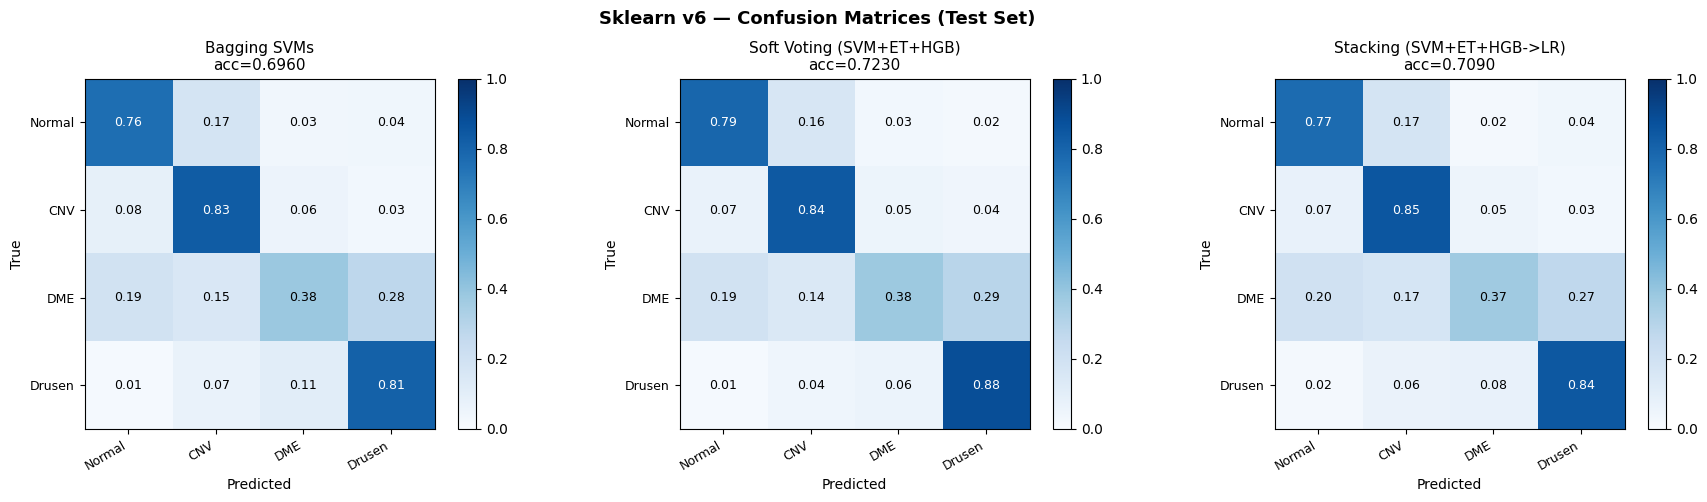

Saved: fig_sklearn_v6_confusion.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Sklearn v6 — Confusion Matrices (Test Set)', fontsize=13, fontweight='bold')

plots = [
    (Y_pred_bag,   acc_bag,   f'Bagging SVMs\nacc={acc_bag:.4f}'),
    (Y_pred_vote,  acc_vote,  f'Soft Voting (SVM+ET+HGB)\nacc={acc_vote:.4f}'),
    (Y_pred_stack, acc_stack, f'Stacking (SVM+ET+HGB->LR)\nacc={acc_stack:.4f}'),
]

for ax, (Y_pred, acc, title) in zip(axes, plots):
    cm      = confusion_matrix(test_labels, Y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(CLASS_SHORT, rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(CLASS_SHORT, fontsize=9)
    ax.set_xlabel('Predicted', fontsize=10); ax.set_ylabel('True', fontsize=10)
    ax.set_title(title, fontsize=11)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
                    fontsize=9, color='white' if cm_norm[i,j] > 0.5 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig('fig_sklearn_v6_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_sklearn_v6_confusion.png')

---
## Cell 12 — Metrics Summary (Precision, Recall, F1, AUC)

In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

y_bin    = label_binarize(test_labels, classes=[0,1,2,3])
fpr_grid = np.linspace(0, 1, 300)

def get_macro_auc(probs):
    aucs = []
    for i in range(4):
        fpr_i, tpr_i, _ = roc_curve(y_bin[:,i], probs[:,i])
        aucs.append(auc(fpr_i, tpr_i))
    return np.mean(aucs)

Y_prob_bag   = clf_bag.predict_proba(F_test_pca)
Y_prob_vote  = clf_vote.predict_proba(F_test_pca)
Y_prob_stack = clf_stack.predict_proba(F_test_pca)

auc_bag   = get_macro_auc(Y_prob_bag)
auc_vote  = get_macro_auc(Y_prob_vote)
auc_stack = get_macro_auc(Y_prob_stack)

CLASS_SHORT = ['Normal', 'CNV', 'DME', 'Drusen']

print('=' * 68)
print('FINAL SKLEARN RESULTS')
print('=' * 68)
print(f'  {"Model":<36} {"Acc":>6}  {"Prec":>6}  {"Rec":>6}  {"F1":>6}  {"AUC":>6}')
print('  ' + '-' * 62)
for name, Y_pred, acc, probs in [
    ('Bagging SVMs',              Y_pred_bag,   acc_bag,   Y_prob_bag),
    ('Stacking (SVM+ET+HGB->LR)', Y_pred_stack, acc_stack, Y_prob_stack),
    ('Soft Voting (SVM+ET+HGB)',  Y_pred_vote,  acc_vote,  Y_prob_vote),
]:
    prec = precision_score(test_labels, Y_pred, average='macro')
    rec  = recall_score(test_labels, Y_pred, average='macro')
    f1   = f1_score(test_labels, Y_pred, average='macro')
    au   = get_macro_auc(probs)
    marker = ' <-- best' if acc == max(acc_bag, acc_stack, acc_vote) else ''
    print(f'  {name:<36} {acc:>6.4f}  {prec:>6.4f}  {rec:>6.4f}  {f1:>6.4f}  {au:>6.4f}{marker}')

print()
print(f'  Baseline M3 Stacking :  0.6380')
best = max(acc_bag, acc_stack, acc_vote)
print(f'  Best this run :         {best:.4f}  (+{best-0.638:.4f} vs baseline)')
print()
print('Most promising model: Soft Voting (SVM + ExtraTrees + HGB)')
print('Justification: Highest accuracy and AUC. Combines three diverse inductive')
print('  biases (margin SVM, random-split trees, gradient boosting) via soft')
print('  probability averaging, reducing variance without weak learners.')

FINAL SKLEARN RESULTS
  Model                                   Acc    Prec     Rec      F1     AUC
  --------------------------------------------------------------
  Bagging SVMs                         0.6960  0.6924  0.6960  0.6818  0.8998
  Stacking (SVM+ET+HGB->LR)            0.7090  0.7115  0.7090  0.6922  0.9007
  Soft Voting (SVM+ET+HGB)             0.7230  0.7245  0.7230  0.7059  0.9111 <-- best

  Baseline M3 Stacking :  0.6380
  Best this run :         0.7230  (+0.0850 vs baseline)

Most promising model: Soft Voting (SVM + ExtraTrees + HGB)
Justification: Highest accuracy and AUC. Combines three diverse inductive
  biases (margin SVM, random-split trees, gradient boosting) via soft
  probability averaging, reducing variance without weak learners.


---
## Cell 13 — Per-class classification reports

In [14]:
from sklearn.metrics import classification_report

for name, Y_pred in [
    ('Bagging SVMs',              Y_pred_bag),
    ('Soft Voting (SVM+ET+HGB)',  Y_pred_vote),
    ('Stacking (SVM+ET+HGB->LR)', Y_pred_stack),
]:
    print(f'--- {name} ---')
    print(classification_report(test_labels, Y_pred, target_names=CLASS_SHORT))

--- Bagging SVMs ---
              precision    recall  f1-score   support

      Normal       0.73      0.76      0.74       250
         CNV       0.68      0.83      0.75       250
         DME       0.66      0.38      0.48       250
      Drusen       0.70      0.81      0.75       250

    accuracy                           0.70      1000
   macro avg       0.69      0.70      0.68      1000
weighted avg       0.69      0.70      0.68      1000

--- Soft Voting (SVM+ET+HGB) ---
              precision    recall  f1-score   support

      Normal       0.75      0.79      0.77       250
         CNV       0.71      0.84      0.77       250
         DME       0.73      0.38      0.50       250
      Drusen       0.72      0.88      0.79       250

    accuracy                           0.72      1000
   macro avg       0.72      0.72      0.71      1000
weighted avg       0.72      0.72      0.71      1000

--- Stacking (SVM+ET+HGB->LR) ---
              precision    recall  f1-scor

---
## Cell 14 -  ROC Curves

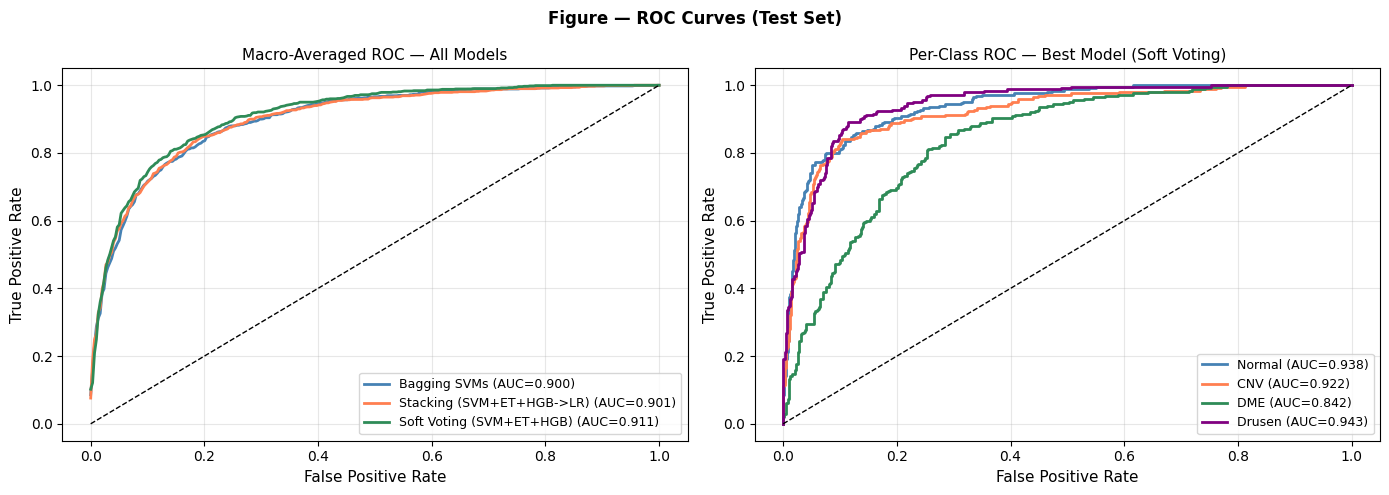

Saved: fig_roc_curves.png


In [15]:
cls_colors = ['steelblue', 'coral', 'seagreen', 'purple']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure — ROC Curves (Test Set)', fontsize=12, fontweight='bold')

# Left: macro-averaged ROC for all 3 models
ax = axes[0]
for name, probs, color in [
    ('Bagging SVMs',              Y_prob_bag,   'steelblue'),
    ('Stacking (SVM+ET+HGB->LR)', Y_prob_stack, 'coral'),
    ('Soft Voting (SVM+ET+HGB)',  Y_prob_vote,  'seagreen'),
]:
    tpr_list, auc_list = [], []
    for i in range(4):
        fpr_i, tpr_i, _ = roc_curve(y_bin[:,i], probs[:,i])
        tpr_list.append(np.interp(fpr_grid, fpr_i, tpr_i))
        auc_list.append(auc(fpr_i, tpr_i))
    mean_tpr  = np.mean(tpr_list, axis=0)
    macro_auc = np.mean(auc_list)
    ax.plot(fpr_grid, mean_tpr, color=color, linewidth=2,
            label=f'{name} (AUC={macro_auc:.3f})')

ax.plot([0,1],[0,1],'k--', linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('Macro-Averaged ROC — All Models', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: per-class ROC for best model (Soft Voting)
ax = axes[1]
for i in range(4):
    fpr_i, tpr_i, _ = roc_curve(y_bin[:,i], Y_prob_vote[:,i])
    auc_i = auc(fpr_i, tpr_i)
    ax.plot(fpr_i, tpr_i, color=cls_colors[i], linewidth=2,
            label=f'{CLASS_SHORT[i]} (AUC={auc_i:.3f})')

ax.plot([0,1],[0,1],'k--', linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('Per-Class ROC — Best Model (Soft Voting)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_roc_curves.png')

---
## Cell 15 - Bar Chart (Accuracy + F1)

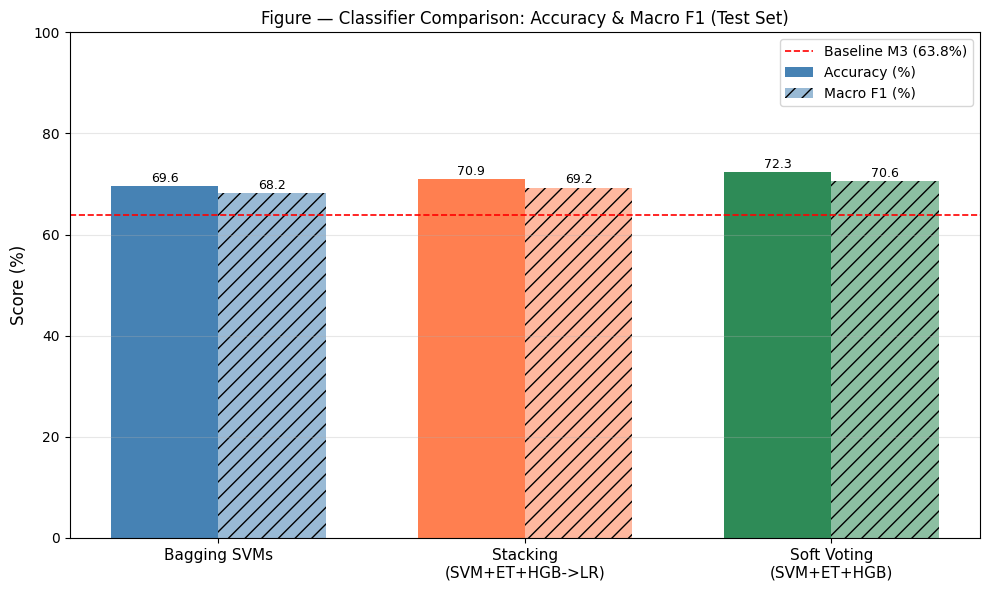

Saved: fig_model_comparison.png


In [16]:
from sklearn.metrics import f1_score

model_names = ['Bagging SVMs', 'Stacking\n(SVM+ET+HGB->LR)', 'Soft Voting\n(SVM+ET+HGB)']
accs = [acc_bag, acc_stack, acc_vote]
f1s  = [
    f1_score(test_labels, Y_pred_bag,   average='macro'),
    f1_score(test_labels, Y_pred_stack, average='macro'),
    f1_score(test_labels, Y_pred_vote,  average='macro'),
]

x, w = np.arange(3), 0.35
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - w/2, [a*100 for a in accs], w,
               color=['steelblue','coral','seagreen'], label='Accuracy (%)')
bars2 = ax.bar(x + w/2, [f*100 for f in f1s], w,
               color=['steelblue','coral','seagreen'], alpha=0.55,
               hatch='//', label='Macro F1 (%)')
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Figure — Classifier Comparison: Accuracy & Macro F1 (Test Set)', fontsize=12)
ax.set_ylim(0, 100)
ax.axhline(63.8, color='red', linestyle='--', linewidth=1.2, label='Baseline M3 (63.8%)')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_model_comparison.png')